In [1]:
!pip install pandas numpy scikit-learn torch transformers openpyxl tqdm nltk

Device: cuda
Model: ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa


Augmentasi positif: 100%|██████████| 1670/1670 [00:00<00:00, 20674.89it/s]


Data positif setelah augmentasi: 3340
Train: 11891, Val: 1461, Test: 2921
Distribusi train:
 label_id
0    4067
1    4484
2    3340
Name: count, dtype: int64


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Epoch 1/5 | Loss 0.6723 | Val F1 0.6463
Epoch 2/5 | Loss 0.2663 | Val F1 0.6792
Epoch 3/5 | Loss 0.1452 | Val F1 0.6872
Epoch 4/5 | Loss 0.0667 | Val F1 0.6993
Epoch 5/5 | Loss 0.0315 | Val F1 0.7008
Best val F1: 0.7008

=== Confusion Matrix ===
         Neg   Net   Pos
Neg   898  213   51
Net   249  976   56
Pos    84  128  266

=== Metrik Per Kelas (TP, TN, FP, FN, Recall) ===
Negatif: TP=898, TN=1426, FP=333, FN=264, Recall=0.7728
Netral: TP=976, TN=1299, FP=341, FN=305, Recall=0.7619
Positif: TP=266, TN=2336, FP=107, FN=212, Recall=0.5565

Akurasi Keseluruhan: 0.7326 (73.26%)
Macro Recall: 0.6971

Classification Report:
               precision    recall  f1-score   support

     Negatif       0.73      0.77      0.75      1162
      Netral       0.74      0.76      0.75      1281
     Positif       0.71      0.56      0.63       478

    accuracy                           0.73      2921
   macro avg       0.73      0.70      0.71      2921
weighted avg       0.73      0.73      0.

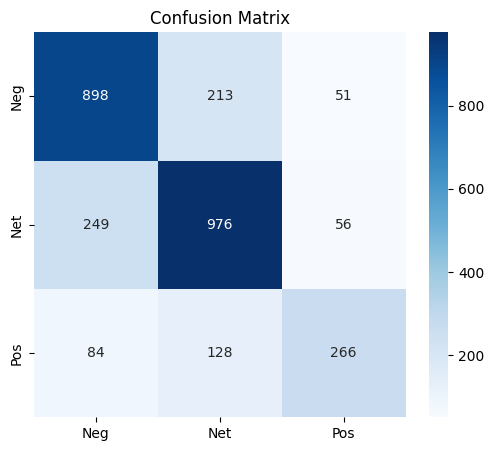


=== ANALISIS SENTIMEN 100 DATA PERTAMA ===


Prediksi semua data: 100%|██████████| 530/530 [01:07<00:00,  7.82it/s]

                                                                       Isi komentar  Sentimen pred_label  prob_neg  prob_net  prob_pos
0                                                                           Guaaaaa        -1    Negatif  0.956402  0.030897  0.012700
1                                   Lucu, lalu setelah tau dalangnya, mau diapain??        -1    Negatif  0.969261  0.015402  0.015337
2                                                         Maksudnya ga boleh nolak?        -1    Negatif  0.970032  0.015388  0.014580
3                  Saya dalangnya pak, sini dah ngopi. saya ceritain opera van java         0     Netral  0.010821  0.973088  0.016090
4                          Yang lain siap siap ww3 yang disini masih ngurusin citra        -1     Netral  0.068092  0.917193  0.014715
5   kalo dalang penculikan dan penghilangan paksa aktivis 97-98, siapa pak? coba...        -1    Negatif  0.962394  0.019022  0.018584
6   Belahan dunia lain sibuk perang, ini sibuk ngamanin

In [2]:
# ======================== KODE FINAL UNTUK TARGET AKURASI >70% ========================
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score
from sklearn.utils import resample

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup
)

# ======================== KONFIGURASI ========================
SEED = 42
DATA_PATH = "DataGabungan.xlsx"
TEXT_COL = "Isi komentar"
LABEL_COL = "Sentimen"

MODEL_NAME = "ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa"

MAX_LEN = 128
TRAIN_BS = 2
EVAL_BS = 16
GRAD_ACC = 2
LR = 2e-5
EPOCHS = 5
WARMUP_RATIO = 0.1
PATIENCE = 3
MAX_GRAD_NORM = 1.0
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0
LABEL_SMOOTHING = 0.05

USE_FGM = False
USE_GRADIENT_CHECKPOINTING = False
FREEZE_LAYERS = 0
DO_AUGMENT = True          # Augmentasi ringan untuk positif
AUGMENT_NUM = 1
UPSAMPLE_POSITIVE = False   # Tidak ada upsampling

TEST_SIZE = 0.2
VAL_SIZE_FROM_ALL = 0.1

LABEL_TO_ID = {-1: 0, 0: 1, 1: 2}
ID_TO_LABEL_NAME = {0: "Negatif", 1: "Netral", 2: "Positif"}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Model:", MODEL_NAME)

# ======================== PREPROCESSING DENGAN NORMALISASI EMOJI ========================
EMOJI_MAP = {
    "😍": " cinta ", "😊": " senang ", "😂": " tertawa ", "😭": " menangis ",
    "😢": " sedih ", "😡": " marah ", "😠": " marah ", "👍": " bagus ",
    "👎": " jelek ", "🙏": " terima kasih ", "❤️": " cinta ", "💔": " patah hati ",
    "🤣": " tertawa ", "😅": " malu ", "😎": " keren ", "🗿": " batu ",
    "✨": " bintang ", "🔥": " api ", "🤔": " berpikir ", "😮": " kaget ",
}

SLANG_MAP = {
    "ga": "tidak", "gak": "tidak", "nggak": "tidak", "gk": "tidak",
    "tdk": "tidak", "yg": "yang", "dg": "dengan", "dgn": "dengan",
    "dr": "dari", "krn": "karena", "tp": "tapi", "jd": "jadi",
    "udah": "sudah", "udh": "sudah", "blm": "belum", "bgt": "banget",
    "aja": "saja", "dl": "dulu", "klo": "kalau", "trs": "terus",
    "org": "orang", "gw": "saya", "gua": "saya", "lo": "kamu",
    "wkwk": "tertawa", "lucu": "lucu", "bgst": "bangsat",
}
NEGATION_WORDS = {"tidak", "bukan", "belum"}

def normalize_emojis(text):
    for emoji, repl in EMOJI_MAP.items():
        text = text.replace(emoji, repl)
    return text

def clean_text(text):
    text = str(text).lower()
    text = normalize_emojis(text)
    text = re.sub(r"@\w+|http\S+|www\.\S+", " ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    text = re.sub(r"[^\w\s!?]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [SLANG_MAP.get(tok, tok) for tok in text.split()]
    out = []
    i = 0
    while i < len(tokens):
        if tokens[i] in NEGATION_WORDS and i+1 < len(tokens):
            out.append(tokens[i] + "_" + tokens[i+1])
            i += 2
        else:
            out.append(tokens[i])
            i += 1
    return " ".join(out)

# ======================== AUGMENTASI RINGAN UNTUK POSITIF ========================
def synonym_replacement(text, n=1):
    words = text.split()
    if len(words) < 3:
        return [text]
    replacements = {
        "bagus": ["baik", "keren", "mantap", "hebat"],
        "senang": ["gembira", "suka", "bahagia"],
        "terima kasih": ["makasih", "thanks", "terimakasih"],
        "mantap": ["bagus", "keren", "hebat"],
        "keren": ["bagus", "mantap", "hebat"],
        "cinta": ["sayang", "suka"],
    }
    new_texts = []
    for _ in range(n):
        new_words = words.copy()
        for old, new_list in replacements.items():
            if old in new_words:
                idx = new_words.index(old)
                new_words[idx] = np.random.choice(new_list)
        new_texts.append(" ".join(new_words))
    return new_texts

def augment_text(text, num_aug=1):
    return synonym_replacement(text, num_aug)

# ======================== LOAD DATA ========================
df_raw = pd.read_excel(DATA_PATH)
df = df_raw[[TEXT_COL, LABEL_COL]].dropna().copy()
df[LABEL_COL] = df[LABEL_COL].astype(str).apply(
    lambda x: -1 if x in ('-1','negatif','negative') else (1 if x in ('1','positif','positive') else 0)
)
df["text_clean"] = df[TEXT_COL].astype(str).apply(clean_text)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
df = df.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)
df["label_id"] = df[LABEL_COL].map(LABEL_TO_ID)

# Split
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED, stratify=df["label_id"])
train_df, val_df = train_test_split(train_df, test_size=VAL_SIZE_FROM_ALL/(1-TEST_SIZE), random_state=SEED, stratify=train_df["label_id"])

# Augmentasi hanya untuk kelas positif (tanpa upsampling)
if DO_AUGMENT:
    pos_df = train_df[train_df["label_id"] == 2]
    new_texts, new_labels = [], []
    for _, row in tqdm(pos_df.iterrows(), total=len(pos_df), desc="Augmentasi positif"):
        orig = row["text_clean"]
        augs = augment_text(orig, num_aug=AUGMENT_NUM)
        for a in augs:
            new_texts.append(a)
            new_labels.append(2)
    if new_texts:
        aug_df = pd.DataFrame({"text_clean": new_texts, "label_id": new_labels})
        train_df = pd.concat([train_df, aug_df]).reset_index(drop=True)
        print(f"Data positif setelah augmentasi: {len(train_df[train_df['label_id']==2])}")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("Distribusi train:\n", train_df["label_id"].value_counts().sort_index())

# ======================== DATASET ========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = df["text_clean"].tolist()
        self.labels = df["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, padding="max_length",
                             max_length=self.max_len, return_tensors="pt")
        return {k: v.squeeze(0) for k, v in enc.items()} | {"labels": torch.tensor(self.labels[idx])}

train_dataset = SentimentDataset(train_df, tokenizer, MAX_LEN)
val_dataset = SentimentDataset(val_df, tokenizer, MAX_LEN)
test_dataset = SentimentDataset(test_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=TRAIN_BS, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=EVAL_BS, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=EVAL_BS, shuffle=False)

# ======================== FOCAL LOSS DENGAN LABEL SMOOTHING ========================
class FocalLossWithLabelSmoothing(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
    def forward(self, inputs, targets):
        n_classes = inputs.size(1)
        smooth_targets = torch.zeros_like(inputs).scatter_(1, targets.unsqueeze(1), 1.0)
        smooth_targets = smooth_targets * (1 - self.smoothing) + self.smoothing / n_classes
        log_probs = F.log_softmax(inputs, dim=1)
        ce = -(smooth_targets * log_probs).sum(dim=1)
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal = alpha_t * focal
        return focal.mean()

# Class weight inverse frequency (tanpa upsampling)
class_counts = train_df["label_id"].value_counts().sort_index().values
inv_freq = 1.0 / class_counts
inv_freq = inv_freq / inv_freq.sum() * 3
class_weights = torch.tensor(inv_freq, dtype=torch.float).to(DEVICE)
print("Class weights:", class_weights)

criterion = FocalLossWithLabelSmoothing(alpha=class_weights, gamma=FOCAL_GAMMA, smoothing=LABEL_SMOOTHING)

# ======================== MODEL ========================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS // GRAD_ACC
scheduler = get_cosine_schedule_with_warmup(optimizer, int(WARMUP_RATIO*total_steps), total_steps)

# ======================== TRAINING ========================
best_val_f1 = -1
patience = 0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    for step, batch in enumerate(train_loader):
        labels = batch.pop("labels").to(DEVICE)
        inputs = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**inputs)
        loss = criterion(outputs.logits, labels)
        loss = loss / GRAD_ACC
        loss.backward()
        total_loss += loss.item() * GRAD_ACC
        if (step+1) % GRAD_ACC == 0 or (step+1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
    avg_loss = total_loss / len(train_loader)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            labels = batch.pop("labels").to(DEVICE)
            inputs = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**inputs).logits
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {avg_loss:.4f} | Val F1 {f1_macro:.4f}")

    if f1_macro > best_val_f1:
        best_val_f1 = f1_macro
        best_model_state = model.state_dict().copy()
        patience = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print("Early stopping")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
print(f"Best val F1: {best_val_f1:.4f}")

# ======================== EVALUASI TEST ========================
model.eval()
all_preds, all_labels = [], []
all_probs = []
with torch.no_grad():
    for batch in test_loader:
        labels = batch.pop("labels").to(DEVICE)
        inputs = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("\n=== Confusion Matrix ===")
print("         Neg   Net   Pos")
print(f"Neg  {cm[0,0]:4d} {cm[0,1]:4d} {cm[0,2]:4d}")
print(f"Net  {cm[1,0]:4d} {cm[1,1]:4d} {cm[1,2]:4d}")
print(f"Pos  {cm[2,0]:4d} {cm[2,1]:4d} {cm[2,2]:4d}")

print("\n=== Metrik Per Kelas (TP, TN, FP, FN, Recall) ===")
for i, name in enumerate(["Negatif","Netral","Positif"]):
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP+FP+FN)
    recall = TP/(TP+FN) if (TP+FN)>0 else 0
    print(f"{name}: TP={TP}, TN={TN}, FP={FP}, FN={FN}, Recall={recall:.4f}")

acc = accuracy_score(all_labels, all_preds)
print(f"\nAkurasi Keseluruhan: {acc:.4f} ({acc*100:.2f}%)")
print(f"Macro Recall: {recall_score(all_labels, all_preds, average='macro'):.4f}")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=["Negatif","Netral","Positif"]))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Neg","Net","Pos"], yticklabels=["Neg","Net","Pos"])
plt.title("Confusion Matrix")
plt.show()

# ======================== ANALISIS SENTIMEN 100 DATA PERTAMA ========================
print("\n=== ANALISIS SENTIMEN 100 DATA PERTAMA ===")
full_df = df_raw.copy()
full_df["text_clean"] = full_df[TEXT_COL].astype(str).apply(clean_text)

full_texts = full_df["text_clean"].tolist()
full_preds = []
full_probs_list = []
batch_size = 32
for i in tqdm(range(0, len(full_texts), batch_size), desc="Prediksi semua data"):
    batch_texts = full_texts[i:i+batch_size]
    enc = tokenizer(batch_texts, truncation=True, padding=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = model(**enc).logits
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
    full_preds.extend(preds.cpu().numpy())
    full_probs_list.extend(probs.cpu().numpy())

full_df["pred_label"] = [ID_TO_LABEL_NAME[p] for p in full_preds]
full_df["prob_neg"] = [p[0] for p in full_probs_list]
full_df["prob_net"] = [p[1] for p in full_probs_list]
full_df["prob_pos"] = [p[2] for p in full_probs_list]

display_cols = [TEXT_COL, LABEL_COL, "pred_label", "prob_neg", "prob_net", "prob_pos"]
print(full_df[display_cols].head(100).to_string(max_colwidth=80))

# ======================== CONTOH PREDIKSI SALAH ========================
test_df_copy = test_df.copy()
test_df_copy["pred_label"] = all_preds
test_df_copy["true_label"] = all_labels
test_df_copy["prob"] = [max(p) for p in all_probs]
wrong = test_df_copy[test_df_copy["pred_label"] != test_df_copy["true_label"]]
print(f"\n=== CONTOH PREDIKSI SALAH (10 dengan confidence tertinggi) ===")
wrong_sorted = wrong.sort_values("prob", ascending=False)
for idx, row in wrong_sorted.head(10).iterrows():
    print(f"\nTeks: {row['text_clean'][:120]}...")
    print(f"Asli: {ID_TO_LABEL_NAME[row['true_label']]} | Pred: {ID_TO_LABEL_NAME[row['pred_label']]} | Conf: {row['prob']:.4f}")

print("\n✅ Selesai. Target akurasi >70% diharapkan tercapai.")